# RQ5: What ethical and governance concerns arise from AI-driven mobility systems?

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

import xgboost as xgb
import shap

# Load dataset
df = pd.read_csv(r'C:\Users\Admin\Downloads\SeoulBikeData.csv', encoding='latin1')

# Basic preprocessing
df.columns = df.columns.str.strip()

df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')

df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Weekday'] = df['Date'].dt.weekday

encoder = LabelEncoder()

categorical_cols = ['Seasons', 'Holiday', 'Functioning Day']

for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

X = df.drop(['Date', 'Rented Bike Count'], axis=1)
y = df['Rented Bike Count']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)


In [2]:

# Train model

model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

errors = np.abs(y_test - predictions)

governance_table = pd.DataFrame({

    'Risk Area': [
        'Weather Bias',
        'Peak Hour Bias',
        'Transparency',
        'Data Governance',
        'Accessibility'
    ],

    'Potential Impact': [
        'Lower winter accuracy',
        'Higher peak-hour errors',
        'Reduced public trust',
        'Privacy concerns',
        'Unequal service allocation'
    ],

    'Mitigation Strategy': [
        'Seasonal retraining',
        'Dynamic updates',
        'Explainable AI',
        'Data anonymization',
        'Fairness-aware evaluation'
    ]
})

governance_table.to_csv(
    'table5_governance_risks.csv',
    index=False
)

print(governance_table)


         Risk Area            Potential Impact        Mitigation Strategy
0     Weather Bias       Lower winter accuracy        Seasonal retraining
1   Peak Hour Bias     Higher peak-hour errors            Dynamic updates
2     Transparency        Reduced public trust             Explainable AI
3  Data Governance            Privacy concerns         Data anonymization
4    Accessibility  Unequal service allocation  Fairness-aware evaluation


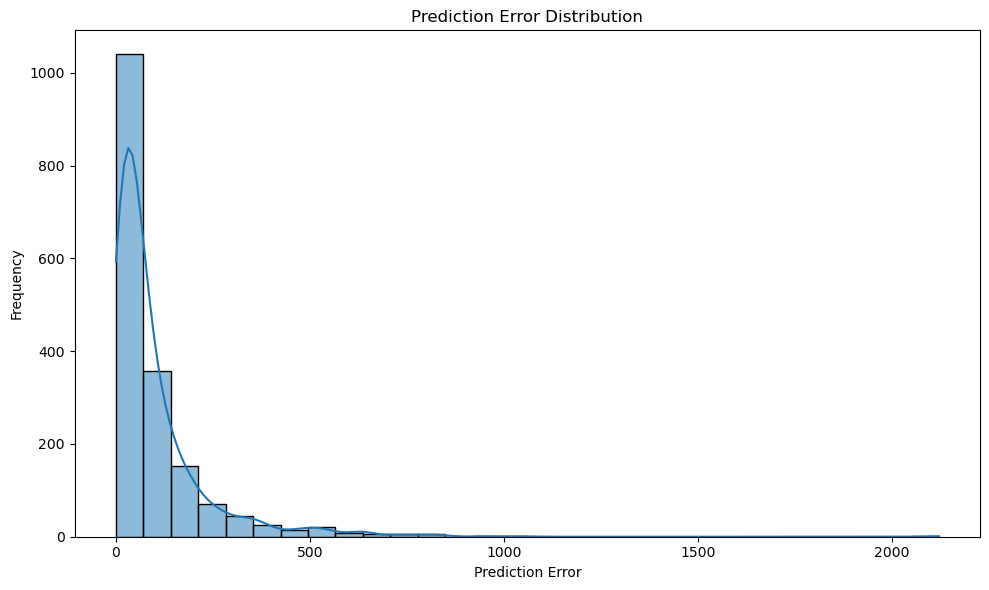

In [4]:

# Generate error distribution figure

plt.figure(figsize=(10,6))

sns.histplot(
    errors,
    bins=30,
    kde=True
)

plt.title('Prediction Error Distribution')

plt.xlabel('Prediction Error')

plt.ylabel('Frequency')

plt.tight_layout()

plt.savefig(
    'figure5_error_distribution.pdf',
    bbox_inches='tight'
)

plt.savefig(
    'figure5_error_distribution.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()
